In [92]:
import pandas as pd
import numpy as np

df=pd.read_csv('workout_fitness_tracker_data.csv')
df.head()

,User ID,Age,Gender,Height (cm),Weight (kg),Workout Type,Workout Duration (mins),Calories Burned,Heart Rate (bpm),Steps Taken,Distance (km),Workout Intensity,Sleep Hours,Water Intake (liters),Daily Calories Intake,Resting Heart Rate (bpm),VO2 Max,Body Fat (%),Mood Before Workout,Mood After Workout
0,1,39,Male,175,99,Cycling,79,384,112,8850,14.44,High,8.2,1.9,3195,61,38.4,28.5,Tired,Fatigued
1,2,36,Other,157,112,Cardio,73,612,168,2821,1.10,High,8.6,1.9,2541,73,38.4,28.5,Happy,Energized
2,3,25,Female,180,66,HIIT,27,540,133,18898,7.28,High,9.8,1.9,3362,80,38.4,28.5,Happy,Fatigued
3,4,56,Male,154,89,Cycling,39,672,118,14102,6.55,Medium,5.8,1.9,2071,65,38.4,28.5,Neutral,Neutral
4,5,53,Other,194,59,Strength,56,410,170,16518,3.17,Medium,7.3,1.9,3298,59,38.4,28.5,Stressed,Energized


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   User ID                   10000 non-null  int64  
 1   Age                       10000 non-null  int64  
 2   Gender                    10000 non-null  object 
 3   Height (cm)               10000 non-null  int64  
 4   Weight (kg)               10000 non-null  int64  
 5   Workout Type              10000 non-null  object 
 6   Workout Duration (mins)   10000 non-null  int64  
 7   Calories Burned           10000 non-null  int64  
 8   Heart Rate (bpm)          10000 non-null  int64  
 9   Steps Taken               10000 non-null  int64  
 10  Distance (km)             10000 non-null  float64
 11  Workout Intensity         10000 non-null  object 
 12  Sleep Hours               10000 non-null  float64
 13  Water Intake (liters)     10000 non-null  float64
 14  Daily C

In [94]:
print(df['Workout Duration (mins)'].mean())

64.4648


In [97]:

def generate_dropout_label(row):
    before = row['Mood Before Workout']
    after = row['Mood After Workout']
    intensity = row['Workout Intensity']
    duration = row['Workout Duration (mins)']

    if(before in ['Tired', 'Stressed','Neutral'] and after in ['Fatigued', 'Neutral'] and intensity in ['Low'] and duration<30):
        return 1
    return 0  

df['Dropout']=df.apply(generate_dropout_label,axis=1)
df.head(50)


,User ID,Age,Gender,Height (cm),Weight (kg),Workout Type,Workout Duration (mins),Calories Burned,Heart Rate (bpm),Steps Taken,...,Workout Intensity,Sleep Hours,Water Intake (liters),Daily Calories Intake,Resting Heart Rate (bpm),VO2 Max,Body Fat (%),Mood Before Workout,Mood After Workout,Dropout
0,1,39,Male,175,99,Cycling,79,384,112,8850,...,High,8.2,1.9,3195,61,38.4,28.5,Tired,Fatigued,0
1,2,36,Other,157,112,Cardio,73,612,168,2821,...,High,8.6,1.9,2541,73,38.4,28.5,Happy,Energized,0
2,3,25,Female,180,66,HIIT,27,540,133,18898,...,High,9.8,1.9,3362,80,38.4,28.5,Happy,Fatigued,0
3,4,56,Male,154,89,Cycling,39,672,118,14102,...,Medium,5.8,1.9,2071,65,38.4,28.5,Neutral,Neutral,0
4,5,53,Other,194,59,Strength,56,410,170,16518,...,Medium,7.3,1.9,3298,59,38.4,28.5,Stressed,Energized,0
5,6,33,Male,162,81,Yoga,11,301,142,10895,...,Low,4.2,1.9,2401,69,38.4,28.5,Happy,Neutral,0
6,7,48,Female,151,82,Strength,109,351,114,4687,...,Low,4.3,1.9,2310,72,38.4,28.5,Happy,Neutral,0
7,8,59,Male,189,61,Strength,83,518,159,11234,...,Medium,8.8,1.9,2654,62,38.4,28.5,Neutral,Neutral,0
8,9,37,Other,182,113,Running,25,226,123,9372,...,Low,4.1,1.9,3760,53,38.4,28.5,Tired,Neutral,1
9,10,45,Female,198,74,Cycling,60,265,171,19073,...,High,5.6,1.9,1908,53,38.4,28.5,Neutral,Energized,0


In [98]:
df['Dropout'].value_counts()


Dropout
0    9690
1     310
Name: count, dtype: int64

In [99]:
from sklearn.preprocessing import OrdinalEncoder
categorical_columns=df.select_dtypes(include=['object']).columns
categorical_columns=categorical_columns.drop(['Mood Before Workout','Mood After Workout'])
print("Categorical columns:",categorical_columns)
encoding=OrdinalEncoder()
df[categorical_columns]=encoding.fit_transform(df[categorical_columns])
df.head()

Categorical columns: Index(['Gender', 'Workout Type', 'Workout Intensity'], dtype='object')


,User ID,Age,Gender,Height (cm),Weight (kg),Workout Type,Workout Duration (mins),Calories Burned,Heart Rate (bpm),Steps Taken,...,Workout Intensity,Sleep Hours,Water Intake (liters),Daily Calories Intake,Resting Heart Rate (bpm),VO2 Max,Body Fat (%),Mood Before Workout,Mood After Workout,Dropout
0,1,39,1.0,175,99,1.0,79,384,112,8850,...,0.0,8.2,1.9,3195,61,38.4,28.5,Tired,Fatigued,0
1,2,36,2.0,157,112,0.0,73,612,168,2821,...,0.0,8.6,1.9,2541,73,38.4,28.5,Happy,Energized,0
2,3,25,0.0,180,66,2.0,27,540,133,18898,...,0.0,9.8,1.9,3362,80,38.4,28.5,Happy,Fatigued,0
3,4,56,1.0,154,89,1.0,39,672,118,14102,...,2.0,5.8,1.9,2071,65,38.4,28.5,Neutral,Neutral,0
4,5,53,2.0,194,59,4.0,56,410,170,16518,...,2.0,7.3,1.9,3298,59,38.4,28.5,Stressed,Energized,0


In [100]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
numneric_columns=df.drop(columns=['User ID','Mood Before Workout','Mood After Workout','Workout Intensity','Dropout','Gender','Workout Type']).columns
df[numneric_columns]=scaler.fit_transform(df[numneric_columns])
df.head()



,User ID,Age,Gender,Height (cm),Weight (kg),Workout Type,Workout Duration (mins),Calories Burned,Heart Rate (bpm),Steps Taken,...,Workout Intensity,Sleep Hours,Water Intake (liters),Daily Calories Intake,Resting Heart Rate (bpm),VO2 Max,Body Fat (%),Mood Before Workout,Mood After Workout,Dropout
0,1,0.050111,1.0,0.050200,0.698254,1.0,0.456890,-0.645011,-0.607033,-0.292645,...,0.0,0.712363,2.220446e-16,0.622769,-0.733734,7.105427e-15,0.0,Tired,Fatigued,0
1,2,-0.196376,2.0,-1.196315,1.342171,0.0,0.268290,0.229836,1.332514,-1.391595,...,0.0,0.946465,2.220446e-16,-0.289271,0.303773,7.105427e-15,0.0,Happy,Energized,0
2,3,-1.100162,0.0,0.396454,-0.936305,2.0,-1.177644,-0.046431,0.120297,1.538876,...,0.0,1.648773,2.220446e-16,0.855661,0.908986,7.105427e-15,0.0,Happy,Fatigued,0
3,4,1.446870,1.0,-1.404067,0.202933,1.0,-0.800444,0.460059,-0.399225,0.664674,...,2.0,-0.692253,2.220446e-16,-0.944714,-0.387898,7.105427e-15,0.0,Neutral,Neutral,0
4,5,1.200383,2.0,1.365965,-1.283030,4.0,-0.266077,-0.545248,1.401784,1.105056,...,2.0,0.185632,2.220446e-16,0.766409,-0.906652,7.105427e-15,0.0,Stressed,Energized,0


In [101]:
from sklearn.model_selection import train_test_split
import torch
x=df.drop(columns=['User ID','Dropout','Mood Before Workout','Mood After Workout'])
y=df['Dropout']
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
xtraintensor=torch.tensor(xtrain.values,dtype=torch.float32)
ytraintensor=torch.tensor(ytrain.values,dtype=torch.float32).view(-1,1)
xtesttensor=torch.tensor(xtest.values,dtype=torch.float32)
ytesttensor=torch.tensor(ytest.values,dtype=torch.float32).view(-1,1)


Epoch 10, Loss:0.5679064393043518
Epoch 20, Loss:0.4554426670074463
Epoch 30, Loss:0.36712971329689026
Epoch 40, Loss:0.29889822006225586
Epoch 50, Loss:0.2476397156715393
Epoch 60, Loss:0.21051697432994843
Epoch 70, Loss:0.18454141914844513
Epoch 80, Loss:0.16676011681556702
Epoch 90, Loss:0.15463750064373016
Epoch 100, Loss:0.1462744176387787


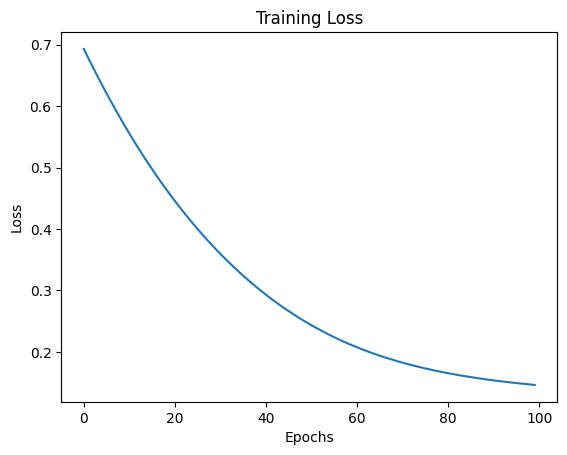

In [ ]:

class MLP(torch.nn.Module):
    def __init__(self,input_size):
        super(MLP, self).__init__()
        self.fc1=torch.nn.Linear(input_size, 64)
        self.relu=torch.nn.ReLU() 
        self.fc2=torch.nn.Linear(64, 1)
        self.sigmoid=torch.nn.Sigmoid()
    def forward(self, x):
        x=self.fc1(x)
        x=self.relu(x)
        x=self.fc2(x)
        x=self.sigmoid(x)
        return x
    
model=MLP(xtrain.shape[1])
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
criterion=torch.nn.BCELoss()

losses=[]
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    outputs=model(xtraintensor)
    loss=criterion(outputs,ytraintensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch+1)%10==0:
        print(f'Epoch {epoch+1}, Loss:{loss.item()}')

import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()



In [105]:
model.eval()
with torch.no_grad():
    testoutputs=model(xtesttensor)
    ypredict=(testoutputs>0.5).float()

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print('Accuracy:',accuracy_score(ytest, ypredict))
print(f'Confusion Matrix:\n',confusion_matrix(ytest,ypredict,labels=[0, 1]))
print(classification_report(ytest,ypredict,labels=[0, 1],zero_division=0))






Accuracy: 0.969
Confusion Matrix:
 [[1938    0]
 [  62    0]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1938
           1       0.00      0.00      0.00        62

    accuracy                           0.97      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.94      0.97      0.95      2000

